In [55]:
import numpy as np
import pandas as pd
data=[120, 125, 122, 126, 124, 600,400]
df=pd.DataFrame({'HousePrice': data})
df

,HousePrice
0,120
1,125
2,122
3,126
4,124
5,600
6,400


In [56]:
#mean
mean=df['HousePrice'].mean()
print(mean)

231.0


In [57]:
#median
median=df['HousePrice'].median()
print(median)

125.0


In [58]:
df['City'] = ['Dhaka', 'Dhaka', 'Chattogram', 'Sylhet', 'Dhaka', 'Rajshahi', 'Chattogram']
df

,HousePrice,City
0,120,Dhaka
1,125,Dhaka
2,122,Chattogram
3,126,Sylhet
4,124,Dhaka
5,600,Rajshahi
6,400,Chattogram


In [59]:
mode=df['City'].mean
print(mode)

<bound method Series.mean of 0         Dhaka
1         Dhaka
2    Chattogram
3        Sylhet
4         Dhaka
5      Rajshahi
6    Chattogram
Name: City, dtype: object>


In [60]:
from sklearn.impute import SimpleImputer
imputer_mean=SimpleImputer(strategy='mean')
impurter_median=SimpleImputer(strategy='median')
imputer_mode=SimpleImputer(strategy='mode')


In [61]:
data=[120, 130, 125, 140, 135, 200, 220]
df=pd.DataFrame({'Purchese': data})
df

,Purchese
0,120
1,130
2,125
3,140
4,135
5,200
6,220


In [62]:
mean=np.mean(df['Purchese'])

pop_var=np.var(df['Purchese'], ddof=0)
samp_var=np.var(df['Purchese'], ddof=1)
pop_sd=np.std(df['Purchese'], ddof=0)
samp_sd=np.std(df['Purchese'], ddof=1)
print(mean)
print(pop_var)
print(samp_var)
print(pop_sd)
print(samp_sd)

152.85714285714286
1370.4081632653058
1598.8095238095236
37.019024342428395
39.98511627855449


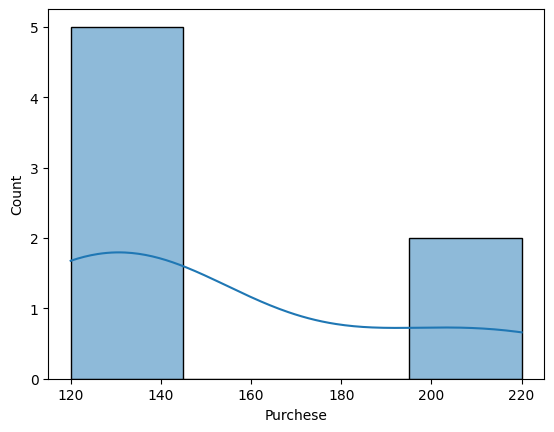

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df,x='Purchese',kde=True)
plt.show()

Text(0.5, 1.0, 'Histogram of Purchese')

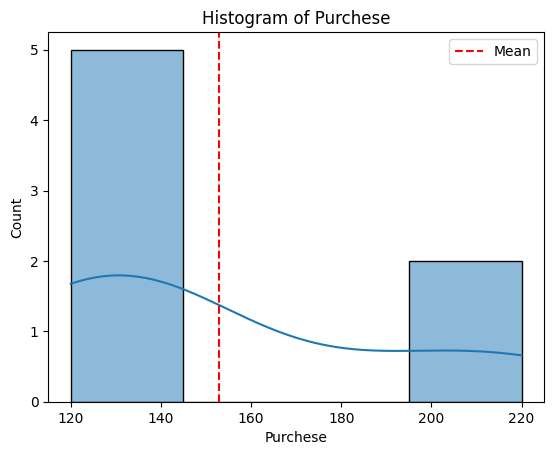

In [64]:
from matplotlib.lines import lineStyles
sns.histplot(df['Purchese'],kde=True)
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.legend()
plt.title('Histogram of Purchese')

In [65]:
#quertile
data=[10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 35, 37, 40]
print('25th q1',np.percentile(data,25))
print('50th q2',np.percentile(data,50))
print('75th q3',np.percentile(data,75))


25th q1 15.0
50th q2 23.0
75th q3 30.0


In [66]:
#iqr
q1=np.percentile(data,25)
q3=np.percentile(data,75)
iqr=q3-q1
print(iqr)

15.0


In [67]:
#lowebound
lower_bound=q1-1.5 * iqr
upper_bound=q3 + 1.5 * iqr

print('lower bound',lower_bound)
print('upper bound',upper_bound)

lower bound -7.5
upper bound 52.5


In [68]:
#Z-SCORE
mean=np.mean(data)
std=np.std(data)
z_score=[(x-mean)/std for x in data]
print(np.round(z_score,2))

[-1.43 -1.22 -1.11 -0.9  -0.59 -0.27 -0.06  0.15  0.46  0.67  1.19  1.4
  1.72]


In [69]:
data=[10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 35, 37, 40]
df=pd.DataFrame({'Age': data})
mean=np.mean(data)
std=np.std(data)
z_score=(df['Age']-mean)/std
print(np.round(z_score,2))

0    -1.43
1    -1.22
2    -1.11
3    -0.90
4    -0.59
5    -0.27
6    -0.06
7     0.15
8     0.46
9     0.67
10    1.19
11    1.40
12    1.72
Name: Age, dtype: float64


In [70]:
df=pd.DataFrame({'Income':[22, 25, 27, 29, 40, 100, 110, 115]})
df

,Income
0,22
1,25
2,27
3,29
4,40
5,100
6,110
7,115


In [71]:
#IQR
q1=df['Income'].quantile(0.25)
q3=df['Income'].quantile(0.75)
iqr=q3-q1
lower_bonund=q1-1.0*iqr
upper_bound=q3+1.0*iqr
print(lower_bonund)
print(upper_bound)

-49.5
178.5


In [72]:
#qurtile outlier
qurtile_iqr=df[(df['Income']<lower_bonund) | (df['Income']>upper_bound)]
print(qurtile_iqr)

Empty DataFrame
Columns: [Income]
Index: []


In [73]:
#z-score outlier
mean=df['Income'].mean()
std=df['Income'].std()
df['z_score']=(df['Income']-mean)/std
print(z_score)
outliers=df[(z_score<-3) | (z_score>3)]
print(outliers)

0    -1.426029
1    -1.216556
2    -1.111819
3    -0.902346
4    -0.588136
5    -0.273926
6    -0.064453
7     0.145020
8     0.459230
9     0.668703
10    1.192386
11    1.401859
12    1.716069
Name: Age, dtype: float64
Empty DataFrame
Columns: [Income, z_score]
Index: []


/tmp/ipykernel_1643/339313898.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers=df[(z_score<-3) | (z_score>3)]


In [74]:
outlier_z=df[np.abs(df['z_score'])>2.5]
print(outlier_z)

Empty DataFrame
Columns: [Income, z_score]
Index: []


In [75]:
#modified z-score (robust)
median=df['Income'].median()
mad=np.median(np.abs(df['Income']-median))
df['mod_z']=0.6745* (df['Income']-median)/mad
outler_mz=df[np.abs(df['mod_z'])>3.5]

#standarzation (z-score)

In [76]:
df=pd.DataFrame({
    'height':[150, 160, 170, 180, 190],
    'Weight':[50, 60, 70, 80, 90]
})
df

,height,Weight
0,150,50
1,160,60
2,170,70
3,180,80
4,190,90


<Axes: >

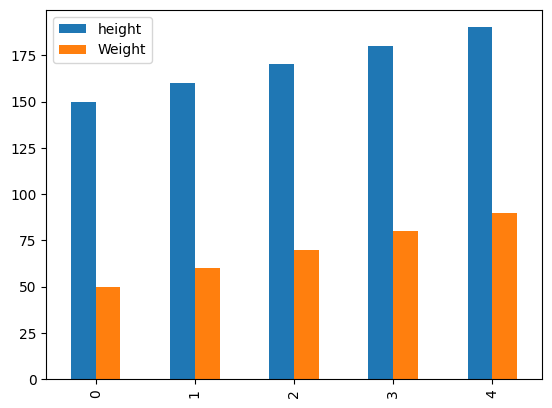

In [77]:
df.plot(kind='bar')

In [78]:
m=df.mean()
s=df.std()
# print(m,s)
z=(df-m)/s
z.round(2)
# print(s)

,height,Weight
0,-1.26,-1.26
1,-0.63,-0.63
2,0.00,0.00
3,0.63,0.63
4,1.26,1.26


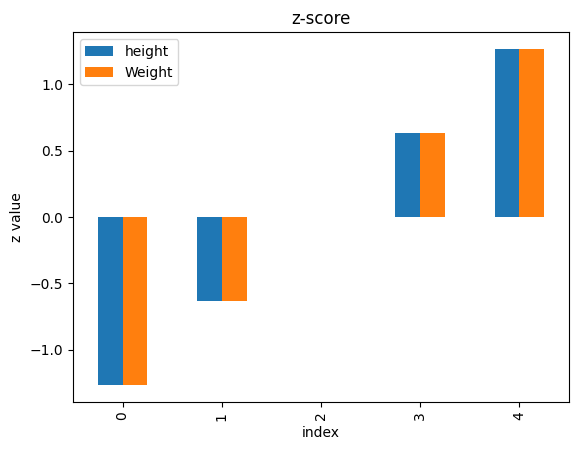

In [79]:
z.plot(kind='bar')
plt.title('z-score')
plt.xlabel('index');plt.ylabel('z value')
plt.show()

# min-mix scaling

In [80]:
import matplotlib.pyplot as plt
df=pd.DataFrame({
    'height':[150, 160, 170, 180, 190],
    'Weight':[50, 60, 70, 80, 90]
})
df

,height,Weight
0,150,50
1,160,60
2,170,70
3,180,80
4,190,90


In [81]:
mn=df.min()
mx=df.max()
rg=mx-mn

min_max=(df-mn)/rg
min_max.round(2)
min_max


,height,Weight
0,0.00,0.00
1,0.25,0.25
2,0.50,0.50
3,0.75,0.75
4,1.00,1.00


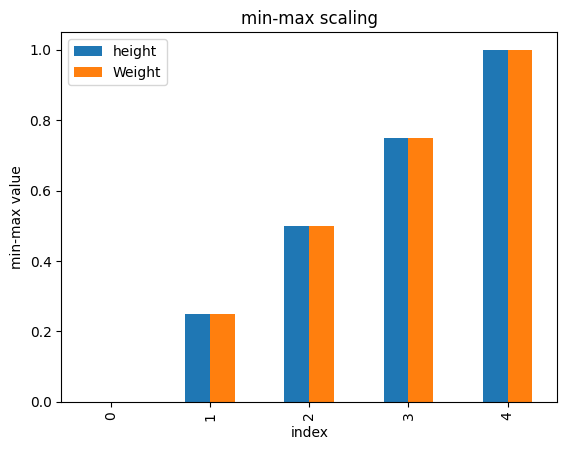

In [82]:
min_max.plot(kind='bar')
plt.title('min-max scaling')
plt.xlabel('index');plt.ylabel('min-max value')
plt.show()

# robust sca

In [83]:
df=pd.DataFrame({
    'height':[150, 160, 170, 180, 300],
    'Weight':[50, 60, 70, 80, 200]
})
df

,height,Weight
0,150,50
1,160,60
2,170,70
3,180,80
4,300,200


In [84]:
md=df.median()
q1=df.quantile(0.25)
q3=df.quantile(0.75)
iqr=q3-q1
md,q1,q3,iqr

(height    170.0
 Weight     70.0
 dtype: float64,
 height    160.0
 Weight     60.0
 Name: 0.25, dtype: float64,
 height    180.0
 Weight     80.0
 Name: 0.75, dtype: float64,
 height    20.0
 Weight    20.0
 dtype: float64)

In [85]:
robust=(df-md)/iqr
robust.round(2)

,height,Weight
0,-1.0,-1.0
1,-0.5,-0.5
2,0.0,0.0
3,0.5,0.5
4,6.5,6.5


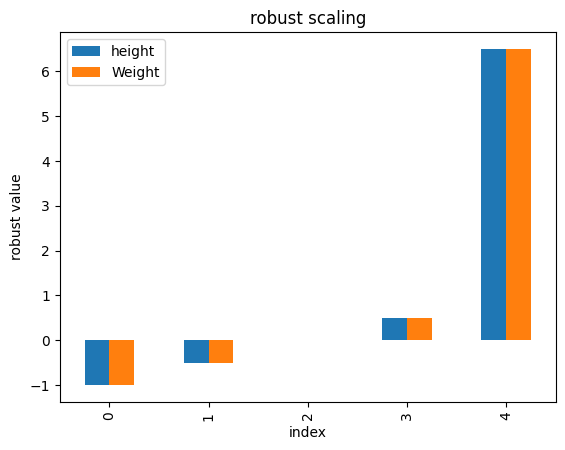

In [86]:
robust.plot(kind='bar')
plt.title('robust scaling')
plt.xlabel('index');plt.ylabel('robust value')
plt.show()

In [87]:
#side by side
out=pd.concat([
    df,
    z.add_prefix('z_'),
    min_max.add_prefix('min_max_'),
    robust.add_prefix('robust_')
],axis=1)
out.round(2)

,height,Weight,z_height,z_Weight,min_max_height,min_max_Weight,robust_height,robust_Weight
0,150,50,-1.26,-1.26,0.00,0.00,-1.0,-1.0
1,160,60,-0.63,-0.63,0.25,0.25,-0.5,-0.5
2,170,70,0.00,0.00,0.50,0.50,0.0,0.0
3,180,80,0.63,0.63,0.75,0.75,0.5,0.5
4,300,200,1.26,1.26,1.00,1.00,6.5,6.5


#one hot encoding

In [88]:
import pandas as pd

df = pd.DataFrame({
    "id":[1,2,3,4],
    "color":["red","blue","green","red"],
    "size":["Small","Medium","Large","Medium"],
    "price":[10,12,15,11]
})
df

,id,color,size,price
0,1,red,Small,10
1,2,blue,Medium,12
2,3,green,Large,15
3,4,red,Medium,11


In [89]:
d_color=pd.get_dummies(df['color'],prefix='Color', dtype=int)
df_encoded=pd.concat([df,d_color],axis=1)
print(df_encoded)

   id  color    size  price  Color_blue  Color_green  Color_red
0   1    red   Small     10           0            0          1
1   2   blue  Medium     12           1            0          0
2   3  green   Large     15           0            1          0
3   4    red  Medium     11           0            0          1


In [90]:
df_encoded=df_encoded.drop('color',axis=1)
print(df_encoded)

   id    size  price  Color_blue  Color_green  Color_red
0   1   Small     10           0            0          1
1   2  Medium     12           1            0          0
2   3   Large     15           0            1          0
3   4  Medium     11           0            0          1


In [91]:
order={'Small':1,'Medium':2,'Large':3}
# df["size_encoded"]=df["size"].map(order).astype(int)
# df

In [92]:
df["size"]=df["size"].map(order).astype(int)
df

,id,color,size,price
0,1,red,1,10
1,2,blue,2,12
2,3,green,3,15
3,4,red,2,11


#dot product

In [93]:
import numpy as np
a=np.array([2, 1, 3])
b=np.array([1,2,3])
a,b

(array([2, 1, 3]), array([1, 2, 3]))

In [94]:
add_ab=a+b
sub_ab=a-b
add_ab,sub_ab

(array([3, 3, 6]), array([ 1, -1,  0]))

In [95]:
#large vlaue  same der ,0 perpen ,neg  op
dot=a@b #np.dot(a,b)
dot

np.int64(13)

In [96]:
l2_a=np.linalg.norm(a)
print(l2_a)

3.7416573867739413


In [97]:
l1_a=np.linalg.norm(a,ord=1)
print(l1_a)

6.0


In [98]:
#UNIT VECTOR
unit_a=a/np.linalg.norm(a)
len_unit_a=np.linalg.norm(unit_a)
print(unit_a,len_unit_a)

[0.53452248 0.26726124 0.80178373] 1.0


#euclidean and manhattan distance

In [99]:
import numpy as np

X = np.array([
    [70, 80],  #S1
    [60, 90],  #S2
    [85, 60],  #S3
    [78, 76],  #S4
    [62, 65],  #S5
], dtype=float)


q=np.array([75,70], dtype=float)

In [106]:
#euclidean distances
eu=np.linalg.norm(X-q,axis=1)
print('euclidean',np.round(eu,3))

euclidean [11.18  25.    14.142  6.708 13.928]


In [107]:
#manhattan distances
ma=np.linalg.norm(X-q,ord=1,axis=1)
print('manhattan',ma.tolist())

manhattan [15.0, 35.0, 20.0, 9.0, 18.0]
